In [43]:
import polars as pl
import pandas as pd
import plotly.express as px

In [44]:
df_pd = pd.read_hdf(r"D:\Taking_mice_top_botoom_26_11_2025\Adam_psilo_LSD_16_12_2025\test_name3_2025-12-26\results\results.h5", key='ranking_ordinal')
df_pl = pl.from_pandas(df_pd)

In [45]:
df_pd = df_pd.reset_index()

In [46]:
df_pd = df_pd[df_pd['phase']=='dark_phase']

In [47]:
df_pl = pl.from_pandas(df_pd)

In [48]:
df_pd

,phase,day,phase_count,0701FA1A04,2B19FA1A04,3B23FA1A04,4937FA1A04,5236FA1A04,61CAF91A04,76BDF91A04,8233FA1A04,D523FD1A04
11,dark_phase,1,1,16.853,20.178,26.082,21.195,15.528,21.982,18.653,17.976,13.808
12,dark_phase,2,2,22.206,21.771,27.526,20.081,18.022,21.860,10.032,22.610,19.626
13,dark_phase,3,3,23.311,24.367,28.035,22.426,18.078,22.282,7.085,22.487,16.658
14,dark_phase,4,4,22.304,27.135,28.895,19.009,19.933,17.684,8.214,23.051,20.573
15,dark_phase,5,5,24.630,26.583,27.525,21.725,21.493,15.488,6.074,23.564,19.886
16,dark_phase,6,6,21.659,27.503,28.107,22.590,19.905,19.198,8.820,20.050,19.906
17,dark_phase,7,7,22.820,28.440,28.142,21.097,20.167,19.062,10.081,19.457,18.796
18,dark_phase,8,8,24.653,22.595,30.839,22.552,17.559,20.446,13.227,17.432,19.320
19,dark_phase,9,9,24.484,23.262,28.645,20.488,19.485,19.758,13.701,17.832,21.307
20,dark_phase,10,10,22.719,23.509,27.781,20.039,21.324,19.558,11.115,21.243,21.637


In [49]:
df_pl = df_pl.drop(['phase', 'day', 'phase_count'])

In [50]:
df_pl

0701FA1A04,2B19FA1A04,3B23FA1A04,4937FA1A04,5236FA1A04,61CAF91A04,76BDF91A04,8233FA1A04,D523FD1A04
f64,f64,f64,f64,f64,f64,f64,f64,f64
16.853,20.178,26.082,21.195,15.528,21.982,18.653,17.976,13.808
22.206,21.771,27.526,20.081,18.022,21.86,10.032,22.61,19.626
23.311,24.367,28.035,22.426,18.078,22.282,7.085,22.487,16.658
22.304,27.135,28.895,19.009,19.933,17.684,8.214,23.051,20.573
24.63,26.583,27.525,21.725,21.493,15.488,6.074,23.564,19.886
21.659,27.503,28.107,22.59,19.905,19.198,8.82,20.05,19.906
22.82,28.44,28.142,21.097,20.167,19.062,10.081,19.457,18.796
24.653,22.595,30.839,22.552,17.559,20.446,13.227,17.432,19.32
24.484,23.262,28.645,20.488,19.485,19.758,13.701,17.832,21.307


In [51]:
s = pl.Series("Phase", range(1, df_pl.height + 1)) #add column with phase count
df_pl.insert_column(0, s)

df_long = df_pl.unpivot(
    index="Phase",
    variable_name="Animal",
    value_name="Rank"
)

In [55]:
df_long

Phase,Animal,Rank
i64,str,u32
1,"""0701FA1A04""",7
2,"""0701FA1A04""",3
3,"""0701FA1A04""",3
4,"""0701FA1A04""",4
5,"""0701FA1A04""",3
…,…,…
6,"""D523FD1A04""",6
7,"""D523FD1A04""",8
8,"""D523FD1A04""",6


In [57]:
#s = pl.Series("Phase", range(1, df_pl.height + 1)) #add column with phase count
#df_pl.insert_column(0, s)
#
#df_long = df_pl.unpivot(
#    index="Phase",
#    variable_name="Animal",
#    value_name="Rank"
#)

order = (
    df_long
    .filter(pl.col("Phase") == 11)
    .sort("Rank", descending=True)
    .select("Animal")
    .to_series()
    .to_list()
)


df_long = df_long.with_columns(
    pl.col("Rank").rank("ordinal", descending=True).over("Phase")
)

#plot graph
fig = px.line(df_long, x='Phase', y='Rank', color='Animal', markers=True, category_orders={'Animal': order})
fig.update_layout(title_text='Daily Rank Trajectories', title_x=.5, width=1000)
fig.update_yaxes(autorange="reversed").update_layout(template="plotly_dark")
fig.show()


In [53]:
df_long

Phase,Animal,Rank
i64,str,u32
1,"""0701FA1A04""",7
2,"""0701FA1A04""",3
3,"""0701FA1A04""",3
4,"""0701FA1A04""",4
5,"""0701FA1A04""",3
…,…,…
6,"""D523FD1A04""",6
7,"""D523FD1A04""",8
8,"""D523FD1A04""",6


In [54]:
chasings.sum().sort_values(ascending=False)

NameError: name 'chasings' is not defined

In [ ]:
rankings

In [ ]:
chasings

0C57FD1A04  1A30FD1A04  \
phase       day phase_count hour chased                               
light_phase 1   1           11   7B32FA1A04         NaN         NaN   
                                 ADC4F91A04         1.0         NaN   
                                 C21EFD1A04         5.0         NaN   
                                 C61DFA1A04         9.0         NaN   
                                 E91AFA1A04         1.0         NaN   
...                                                 ...         ...   
dark_phase  8   7           15   891EFA1A04         1.0         NaN   
                                 ADC4F91A04         6.0         2.0   
                                 C21EFD1A04         1.0         NaN   
                                 C61DFA1A04         1.0         NaN   
                                 E91AFA1A04         1.0         NaN   

                                             34A9F91A04  7B32FA1A04  \
phase       day phase_count hour chased                               
light_phase 1   1           11   7B32FA1A04         NaN         NaN   
                                 ADC4F91A04         NaN         NaN   
                                 C21EFD1A04         NaN         NaN   
                                 C61DFA1A04         NaN         NaN   
                                 E91AFA1A04         NaN         NaN   
...                                                 ...         ...   
dark_phase  8   7           15   891EFA1A04         2.0         NaN   
                                 ADC4F91A04         3.0         3.0   
                                 C21EFD1A04         5.0         NaN   
                                 C61DFA1A04         NaN         NaN   
                                 E91AFA1A04         7.0         1.0   

                                             891EFA1A04  ADC4F91A04  \
phase       day phase_count hour chased                               
light_phase 1   1           11   7B32FA1A04         NaN         NaN   
                                 ADC4F91A04         NaN         NaN   
                                 C21EFD1A04         NaN         NaN   
                                 C61DFA1A04         NaN         NaN   
                                 E91AFA1A04         NaN         NaN   
...                                                 ...         ...   
dark_phase  8   7           15   891EFA1A04         NaN        12.0   
                                 ADC4F91A04         NaN         NaN   
                                 C21EFD1A04         NaN         NaN   
                                 C61DFA1A04         NaN         NaN   
                                 E91AFA1A04         NaN         NaN   

                                             C21EFD1A04  C61DFA1A04  \
phase       day phase_count hour chased                               
light_phase 1   1           11   7B32FA1A04         NaN         2.0   
                                 ADC4F91A04         1.0         NaN   
                                 C21EFD1A04         NaN         NaN   
                                 C61DFA1A04         NaN         NaN   
                                 E91AFA1A04         NaN         NaN   
...                                                 ...         ...   
dark_phase  8   7           15   891EFA1A04         9.0         NaN   
                                 ADC4F91A04         2.0         1.0   
                                 C21EFD1A04         NaN         NaN   
                                 C61DFA1A04         NaN         NaN   
                                 E91AFA1A04         8.0         2.0   

                                             E91AFA1A04  
phase       day phase_count hour chased                  
light_phase 1   1           11   7B32FA1A04         NaN  
                                 ADC4F91A04         NaN  
                                 C21EFD1A04         NaN  
                                 C61DFA1A04         NaN  
 

In [ ]:
del chasings

In [ ]:
chasings.groupby('chaser').sum()

NameError: name 'chasings' is not defined

In [ ]:
import numpy as np

In [ ]:
chasings = chasings.reset_index()

In [ ]:
x = x.drop(columns=['hour', 'day', 'phase'])

KeyError: "['hour', 'day', 'phase'] not found in axis"

In [ ]:
x[x['chased']=='7B32FA1A04'].sum()

TypeError: 'Categorical' with dtype category does not support reduction 'sum'

In [ ]:
id_vars = ["phase_count"]

# all other columns are animal IDs
value_vars = [c for c in x.columns if c not in id_vars]

df_melted = x.melt(
    id_vars= ["phase_count"],
    value_vars=value_vars,
    var_name="animal_id",
    value_name="value"
).dropna(subset=["value"])


In [ ]:
a = activity

In [ ]:
a

0C57FD1A04  1A30FD1A04  \
phase       day phase_count hour position                            
light_phase 1   1           11   cage_1              7           3   
                                 cage_2              8           2   
                                 cage_3             11           2   
                                 cage_4              8           4   
                                 tunnel_1            7           3   
...                                                ...         ...   
dark_phase  7   6           23   tunnel_1            1           1   
                                 tunnel_2           10           7   
                                 tunnel_3           10           9   
                                 tunnel_4           10           6   
                                 undefined           0           0   

                                            34A9F91A04  7B32FA1A04  \
phase       day phase_count hour position                            
light_phase 1   1           11   cage_1             13           1   
                                 cage_2              5           2   
                                 cage_3              3           3   
                                 cage_4              5           2   
                                 tunnel_1            6           1   
...                                                ...         ...   
dark_phase  7   6           23   tunnel_1            3           8   
                                 tunnel_2           15          19   
                                 tunnel_3           17          16   
                                 tunnel_4           16          18   
                                 undefined           0           0   

                                            891EFA1A04  ADC4F91A04  \
phase       day phase_count hour position                            
light_phase 1   1           11   cage_1              0           3   
                                 cage_2              1           3   
                                 cage_3              1           3   
                                 cage_4              1           4   
                                 tunnel_1            1           3   
...                                                ...         ...   
dark_phase  7   6           23   tunnel_1            6           2   
                                 tunnel_2           12          19   
                                 tunnel_3           12          17   
                                 tunnel_4           13          17   
                                 undefined           0           0   

                                            C21EFD1A04  C61DFA1A04  E91AFA1A04  
phase       day phase_count hour position                                       
light_phase 1   1           11   cage_1              1           6           3  
                                 cage_2              4           5           1  
                                 cage_3              7           6           0  
                                 cage_4              3           6           2  
                                 tunnel_1            1           4           3  
...                                                ...         ...         ...  
dark_phase  7   6           23   tunnel_1            1           2           3  
                                 tunnel_2            5          11          18  
                                 tunnel_3            7           9          22  
                                 tunnel_4            4          10          19  
                                 undefined           0           0           1  

[922 rows x 9 columns]

In [ ]:
animal_cols = a.columns[a.columns.str.endswith("04")]


In [ ]:
df_long = a.melt(
    id_vars=[c for c in animal_cols if c not in animal_cols],
    value_vars=animal_cols,
    var_name='animal_id',
    value_name='count'
)

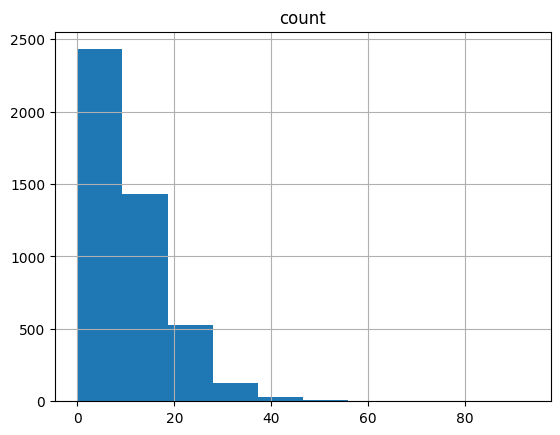

In [ ]:
df_long.hist()
plt.show()

In [ ]:
df_grouped = (
    df_long.groupby(["day", "phase_count", "hour", "position", "animal_id"])["count"]
           .sum()
           .reset_index()
)


KeyError: 'day'

In [ ]:
a = activity.reset_index()

In [ ]:
id_vars = ["phase_count"]

# all other columns are animal IDs
value_vars = [c for c in a.columns if c not in id_vars]

df_melted = a.melt(
    id_vars= ["phase_count"],
    value_vars=value_vars,
    var_name="animal_id",
    value_name="value"
).dropna(subset=["value"])

In [ ]:
df_melted

,phase_count,animal_id,value
0,1,phase,light_phase
1,1,phase,light_phase
2,1,phase,light_phase
3,1,phase,light_phase
4,1,phase,light_phase
...,...,...,...
11981,6,E91AFA1A04,3
11982,6,E91AFA1A04,18
11983,6,E91AFA1A04,22
11984,6,E91AFA1A04,19


In [ ]:
a = activity.reset_index()

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
x = chasings.reset_index()

In [ ]:
phase_6 = df_melted[df_melted['phase_count']==6]

TypeError: 'value' must be an instance of str or bytes, not a float

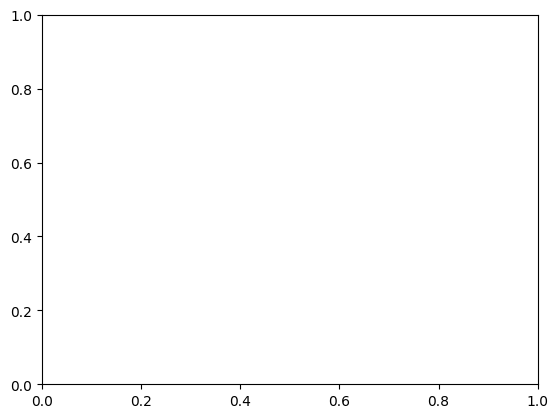

In [ ]:
phase_6['value'].hist()
plt.show()

In [ ]:
print(C2.mean())

TypeError: 'Categorical' with dtype category does not support reduction 'mean'

In [ ]:
df_melted[df_melted['animal_id']=='C21EFD1A04']['value'].agg([np.sum, np.mean, np.median])

C:\Users\abrosnan\AppData\Local\Temp\ipykernel_32384\3125475960.py:1: FutureWarning:

The provided callable <function sum at 0x0000012B9D54C7C0> is currently using Series.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.

C:\Users\abrosnan\AppData\Local\Temp\ipykernel_32384\3125475960.py:1: FutureWarning:

The provided callable <function mean at 0x0000012B9D54DBC0> is currently using Series.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.

C:\Users\abrosnan\AppData\Local\Temp\ipykernel_32384\3125475960.py:1: FutureWarning:

The provided callable <function median at 0x0000012B9D674400> is currently using Series.median. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "median" instead.



sum       554.000000
mean        2.742574
median      2.000000
Name: value, dtype: float64

In [ ]:
p = x.sum().sort_values(ascending=False)

In [ ]:
metric = p/l

In [ ]:
metric.sort_values(ascending=False)

0701FA1A04   NaN
2B19FA1A04   NaN
342FFA1A04   NaN
3B23FA1A04   NaN
4937FA1A04   NaN
5236FA1A04   NaN
61CAF91A04   NaN
6C26FA1A04   NaN
6D3EFD1A04   NaN
73C5F91A04   NaN
76BDF91A04   NaN
8233FA1A04   NaN
8DAEF91A04   NaN
8E36FD1A04   NaN
BD12FA1A04   NaN
C3A6F91A04   NaN
D40AFD1A04   NaN
D523FD1A04   NaN
DD2EFA1A04   NaN
F902FA1A04   NaN
FB34FD1A04   NaN
dtype: float64

In [ ]:
l = activity.sum().sort_values(ascending=False)